# 2D test: reverse-$\mathrm{KL}$ training of a normalizing flow

We train a Neural Spline Flow (NSF) $F$ such that the pushforward of a 2D Gaussian source $\mu_0$ approximates a target $\mu_1$ on $\mathbb{R}^2$ specified only by an unnormalized energy $U_1$.

- **Source:** $\mu_0 = \mathcal{N}(0, I)$ on $\mathbb{R}^2$, with potential $U_0(x) = \tfrac{1}{2}|x|^2$.
- **Target:** $\mu_1 \propto \exp(-U_1)$ with $U_1(x) = \tfrac{1}{2}|x|^2 + 2\cos x_1$.
- **Flow:** $F$ is an NSF with bijection on the box $[-4, 4]^2 \subset \mathbb{R}^2$.

In [1]:
import torch
from zflows import NSF, compute_ESS_log
from zflows.potential import Potential, Gaussian

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Source and target potentials

Both `Potential` subclasses return $U(x)$ for a batch of points $x \in \mathbb{R}^2$. By definition,
$$
\mu_0(x) \propto \exp(-U_0(x)), \qquad \mu_1(y) \propto \exp(-U_1(y)).
$$
We never need the normalizing constant of $\mu_1$, only $U_1$.

In [2]:
# source: U0(x) = (x1^2 + x2^2) / 2  (standard Gaussian)
u0 = Gaussian(mean=[0.0, 0.0], variance=[1.0, 1.0]).to(device)

# target: U1(x) = (x1^2 + x2^2) / 2 + 2*cos(x1)
class U1(Potential):
    def __init__(self):
        super().__init__()
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x1 = x[:, 0]
        x2 = x[:, 1]
        return 0.5 * (x1 ** 2 + x2 ** 2) + 2 * torch.cos(x1)

u1 = U1().to(device)

## Reverse-$\mathrm{KL}$ objective

Let $\nu = F_{\#} \mu_0$ be the pushforward density. With $y = F(x)$ and $x \sim \mu_0$, the change-of-variables formula gives
$$
\log \nu(y) = \log \mu_0(x) - \log |\det J_F(x)| = -U_0(x) - \log |\det J_F(x)|.
$$
The reverse $\mathrm{KL}$ divergence is
$$
\mathrm{KL}(\nu | \mu_1) = \mathbb{E}_{y \sim \nu}\bigl[\log \nu(y) - \log \mu_1(y)\bigr] = \mathbb{E}_{x \sim \mu_0}\bigl[U_1(F(x)) - U_0(x) - \log |\det J_F(x)|\bigr] + \mathrm{const}.
$$
We drop the constant (it does not depend on $F$) and minimize the expectation by Monte Carlo over a batch $\{x_i\}_{i=1}^{N} \sim \mu_0$.

In [3]:
def reverse_KL_loss(x: torch.Tensor, source: Potential, target: Potential, flow: NSF):
    """
    Monte Carlo estimate of  E_{x ~ source}[ U_target(F(x)) - U_source(x) - log|det J_F(x)| ].
    Input:
        x:      Tensor [N, d]   samples drawn from the source distribution
        source: Potential       negative log-density of the source (up to const)
        target: Potential       negative log-density of the target (up to const)
        flow:   NSF             normalizing flow providing F = flow.t()
    Output:
        loss: Tensor (scalar)
    """
    y, ladj = flow.t().call_and_ladj(x)
    return (target(y) - source(x) - ladj).mean()

## Flow and training setup

An NSF acts as a bijection on $[a, b]^d \subset \mathbb{R}^d$; we pick $[-4, 4]^2$ which comfortably covers the high-density region of both $\mu_0$ and $\mu_1$.

In [4]:
flow = NSF(a=[-4, -4], b=[4, 4], bins=8, transforms=4, hidden_features=(64, 64)).to(device)

N: int = 10000     # number of samples
LR: float = 1e-3   # learning rate
BATCH: int = 1000  # batch size
EPOCH: int = 10    # number of epochs

## Training loop

Each epoch shuffles the source samples and takes one mini-batch gradient step per batch. We log the average reverse-$\mathrm{KL}$ across batches.

In [5]:
x = u0.samples(N)
optimizer = torch.optim.Adam(flow.parameters(), lr=LR)

for epoch in range(EPOCH):
    perm = torch.randperm(N, device=device)
    epoch_loss = 0.0
    n_batches = 0
    for start in range(0, N, BATCH):
        idx = perm[start:start + BATCH]
        x_batch = x[idx]

        loss = reverse_KL_loss(x_batch, source=u0, target=u1, flow=flow)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    print(f"epoch {epoch+1:>3}/{EPOCH}   KL_loss = {epoch_loss / n_batches:.6f}")

epoch   1/10   KL_loss = 1.033152
epoch   2/10   KL_loss = 0.688708
epoch   3/10   KL_loss = 0.659976
epoch   4/10   KL_loss = 0.649015
epoch   5/10   KL_loss = 0.639682
epoch   6/10   KL_loss = 0.635936
epoch   7/10   KL_loss = 0.634170
epoch   8/10   KL_loss = 0.633124
epoch   9/10   KL_loss = 0.632881
epoch  10/10   KL_loss = 0.632167


## Importance sampling and $\mathrm{ESS}$

After training, $\nu = F_{\#} \mu_0$ is an approximation of $\mu_1$. Self-normalized importance sampling corrects the residual mismatch. With $y = F(x)$ and $x \sim \mu_0$, the unnormalized weight is
$$
w(y) = \frac{\mu_1(y)}{\nu(y)} \propto \frac{\exp(-U_1(y))}{\exp(-U_0(x) - \log |\det J_F(x)|)},
$$
$$
\log w = -U_1(y) + U_0(x) + \log |\det J_F(x)|.
$$
The Effective Sample Size measures how concentrated the weights are:
$$
\mathrm{ESS} = \frac{\bigl(\sum_{i=1}^{N} w_i\bigr)^2}{N \sum_{i=1}^{N} w_i^2} \in [0, 1].
$$
An $\mathrm{ESS}$ near $1$ means $\nu \approx \mu_1$; near $0$ means a few samples carry almost all the weight. We compute $\mathrm{ESS}$ in log-space (`compute_ESS_log`) using `logsumexp` for numerical stability.

ESS = 0.9901


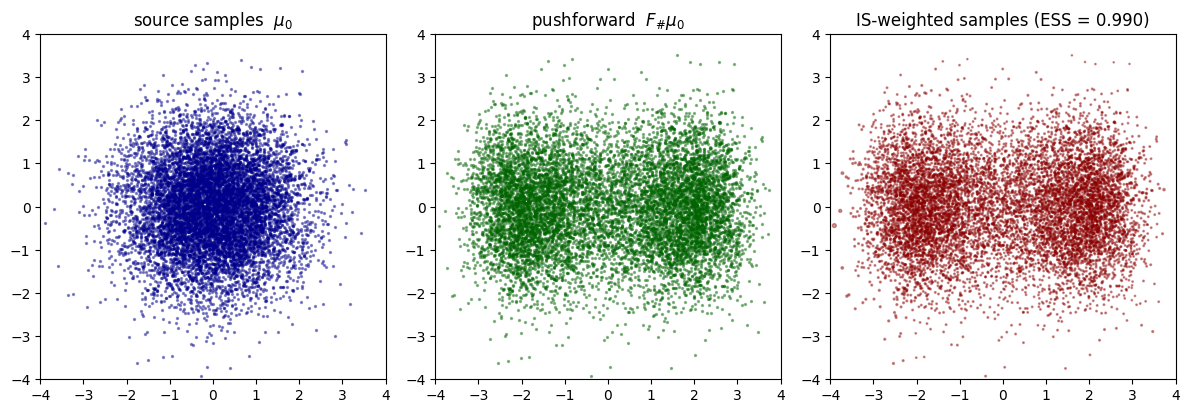

In [6]:
import matplotlib.pyplot as plt

with torch.no_grad():
    x_plot = u0.samples(N)                            # fresh samples from source
    y_plot, ladj = flow.t().call_and_ladj(x_plot)     # pushforward F(x)
    # log w = -U_1(y) + U_0(x) + log|det J_F(x)|
    log_w = -u1(y_plot) + u0(x_plot) + ladj

ess = compute_ESS_log(log_w)
print(f"ESS = {ess.item():.4f}")

x_np = x_plot.cpu().numpy()
y_np = y_plot.cpu().numpy()
w_np = (log_w - log_w.max()).exp().cpu().numpy()  # for marker-size scaling only

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].scatter(x_np[:, 0], x_np[:, 1], s=2, alpha=0.4, color="darkblue")
axes[0].set_title(r"source samples  $\mu_0$")

axes[1].scatter(y_np[:, 0], y_np[:, 1], s=2, alpha=0.4, color="darkgreen")
axes[1].set_title(r"pushforward  $F_\# \mu_0$")

w_norm = w_np / w_np.max()
axes[2].scatter(y_np[:, 0], y_np[:, 1], s=8 * w_norm, alpha=0.4, color="darkred")
axes[2].set_title(f"IS-weighted samples (ESS = {ess.item():.3f})")

for ax in axes:
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()